In [46]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.ensemble import RandomForestClassifier

In [55]:
import sys
!{sys.executable} -m pip install imbalanced-learn

import sys
!{sys.executable} -m pip install xgboost


[notice] A new release of pip is available: 26.1.2 -> 26.2.1
[notice] To update, run: python.exe -m pip install --upgrade pip


   ---------------------------------------- 0.0/48.9 MB ? eta -:--:--
   ---------------------------------------- 0.0/48.9 MB ? eta -:--:--
   ---------------------------------------- 0.3/48.9 MB ? eta -:--:--
   ---------------------------------------- 0.3/48.9 MB ? eta -:--:--
   ---------------------------------------- 0.5/48.9 MB 665.4 kB/s eta 0:01:13
    --------------------------------------- 0.8/48.9 MB 861.5 kB/s eta 0:00:56
    --------------------------------------- 1.0/48.9 MB 969.8 kB/s eta 0:00:50
   - -------------------------------------- 1.3/48.9 MB 1.0 MB/s eta 0:00:47
   - -------------------------------------- 1.6/48.9 MB 1.0 MB/s eta 0:00:47
   - -------------------------------------- 1.6/48.9 MB 1.0 MB/s eta 0:00:47
   - -------------------------------------- 1.8/48.9 MB 959.7 kB/s eta 0:00:50
   - -------------------------------------- 1.8/48.9 MB 959.7 kB/s eta 0:00:50
   - -------------------------------------- 1.8/48.9 MB 959.7 kB/s eta 0:00:50
   - ----------


[notice] A new release of pip is available: 26.1.2 -> 26.2.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [2]:
df = pd.read_csv("../data/FastagFraudDetection.csv")

df.head()

,Transaction_ID,Timestamp,Vehicle_Type,FastagID,TollBoothID,Lane_Type,Vehicle_Dimensions,Transaction_Amount,Amount_paid,Geographical_Location,Vehicle_Speed,Vehicle_Plate_Number,Fraud_indicator
0,1,1/6/2023 11:20,Bus,FTG-001-ABC-121,A-101,Express,Large,350,120,"13.059816123454882, 77.77068662374292",65,KA11AB1234,Fraud
1,2,1/7/2023 14:55,Car,FTG-002-XYZ-451,B-102,Regular,Small,120,100,"13.059816123454882, 77.77068662374292",78,KA66CD5678,Fraud
2,3,1/8/2023 18:25,Motorcycle,NaN,D-104,Regular,Small,0,0,"13.059816123454882, 77.77068662374292",53,KA88EF9012,Not Fraud
3,4,1/9/2023 2:05,Truck,FTG-044-LMN-322,C-103,Regular,Large,350,120,"13.059816123454882, 77.77068662374292",92,KA11GH3456,Fraud
4,5,1/10/2023 6:35,Van,FTG-505-DEF-652,B-102,Express,Medium,140,100,"13.059816123454882, 77.77068662374292",60,KA44IJ6789,Fraud


In [3]:
print("Dataset Shape:", df.shape)

Dataset Shape: (5000, 13)


In [4]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 5000 entries, 0 to 4999
Data columns (total 13 columns):
 #   Column                 Non-Null Count  Dtype
---  ------                 --------------  -----
 0   Transaction_ID         5000 non-null   int64
 1   Timestamp              5000 non-null   str  
 2   Vehicle_Type           5000 non-null   str  
 3   FastagID               4451 non-null   str  
 4   TollBoothID            5000 non-null   str  
 5   Lane_Type              5000 non-null   str  
 6   Vehicle_Dimensions     5000 non-null   str  
 7   Transaction_Amount     5000 non-null   int64
 8   Amount_paid            5000 non-null   int64
 9   Geographical_Location  5000 non-null   str  
 10  Vehicle_Speed          5000 non-null   int64
 11  Vehicle_Plate_Number   5000 non-null   str  
 12  Fraud_indicator        5000 non-null   str  
dtypes: int64(4), str(9)
memory usage: 507.9 KB


In [5]:
df.isnull().sum()

Transaction_ID             0
Timestamp                  0
Vehicle_Type               0
FastagID                 549
TollBoothID                0
Lane_Type                  0
Vehicle_Dimensions         0
Transaction_Amount         0
Amount_paid                0
Geographical_Location      0
Vehicle_Speed              0
Vehicle_Plate_Number       0
Fraud_indicator            0
dtype: int64

Check Class Imbalance

In [6]:
df["Fraud_indicator"].value_counts()

Fraud_indicator
Not Fraud    4017
Fraud         983
Name: count, dtype: int64

In [7]:
df["Fraud_indicator"].value_counts(normalize=True) * 100

Fraud_indicator
Not Fraud    80.34
Fraud        19.66
Name: proportion, dtype: float64

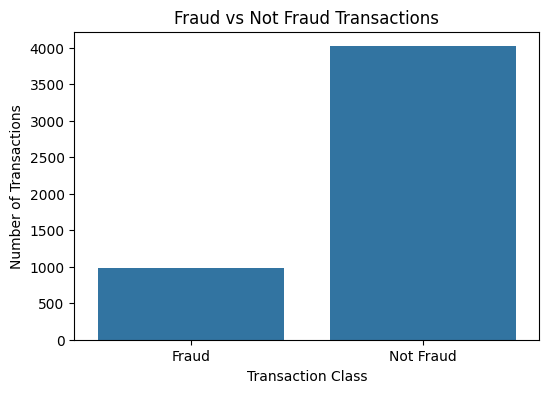

In [11]:
plt.figure(figsize=(6, 4))

sns.countplot(data=df, x="Fraud_indicator")

plt.title("Fraud vs Not Fraud Transactions")
plt.xlabel("Transaction Class")
plt.ylabel("Number of Transactions")
plt.show()

Numerical Data Analysis

In [12]:
df[["Transaction_Amount", "Amount_paid", "Vehicle_Speed"]].describe()

,Transaction_Amount,Amount_paid,Vehicle_Speed
count,5000.00000,5000.000000,5000.000000
mean,161.06200,141.261000,67.851200
std,112.44995,106.480996,16.597547
min,0.00000,0.000000,10.000000
25%,100.00000,90.000000,54.000000
50%,130.00000,120.000000,67.000000
75%,290.00000,160.000000,82.000000
max,350.00000,350.000000,118.000000


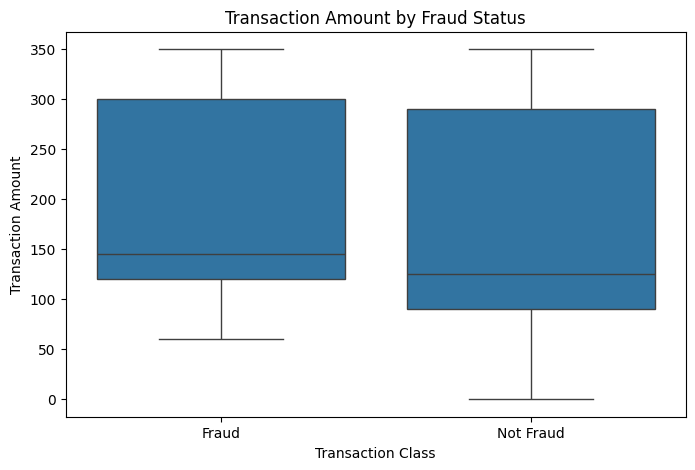

In [13]:
plt.figure(figsize=(8, 5))

sns.boxplot(data=df, x="Fraud_indicator", y="Transaction_Amount")

plt.title("Transaction Amount by Fraud Status")
plt.xlabel("Transaction Class")
plt.ylabel("Transaction Amount")
plt.show()

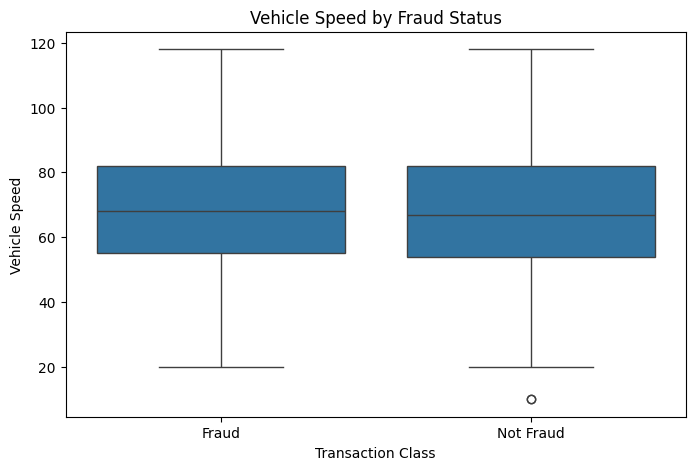

In [14]:
plt.figure(figsize=(8, 5))

sns.boxplot(data=df, x="Fraud_indicator", y="Vehicle_Speed")

plt.title("Vehicle Speed by Fraud Status")
plt.xlabel("Transaction Class")
plt.ylabel("Vehicle Speed")
plt.show()

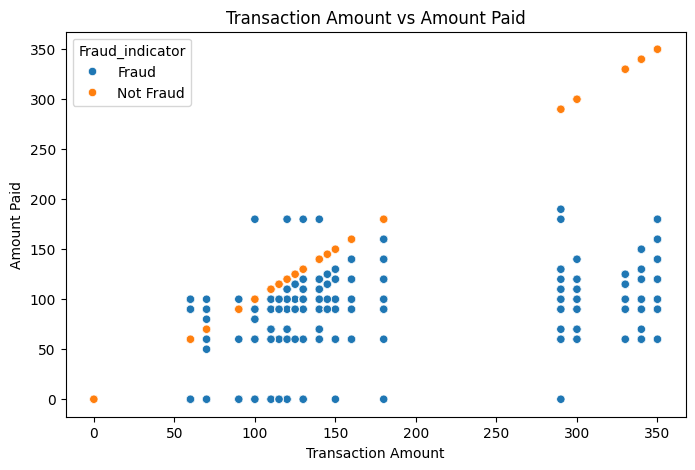

In [15]:
plt.figure(figsize=(8, 5))

sns.scatterplot(
    data=df,
    x="Transaction_Amount",
    y="Amount_paid",
    hue="Fraud_indicator"
)

plt.title("Transaction Amount vs Amount Paid")
plt.xlabel("Transaction Amount")
plt.ylabel("Amount Paid")
plt.show()

Categorical Data Analysis

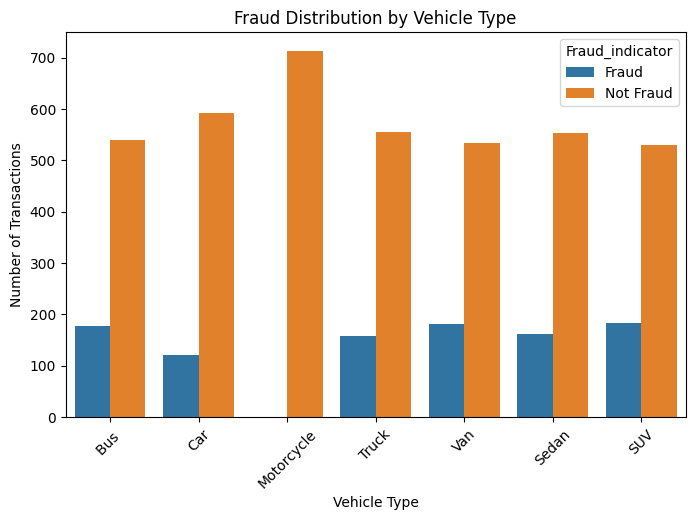

In [16]:
plt.figure(figsize=(8, 5))

sns.countplot(
    data=df,
    x="Vehicle_Type",
    hue="Fraud_indicator"
)

plt.title("Fraud Distribution by Vehicle Type")
plt.xlabel("Vehicle Type")
plt.ylabel("Number of Transactions")
plt.xticks(rotation=45)
plt.show()

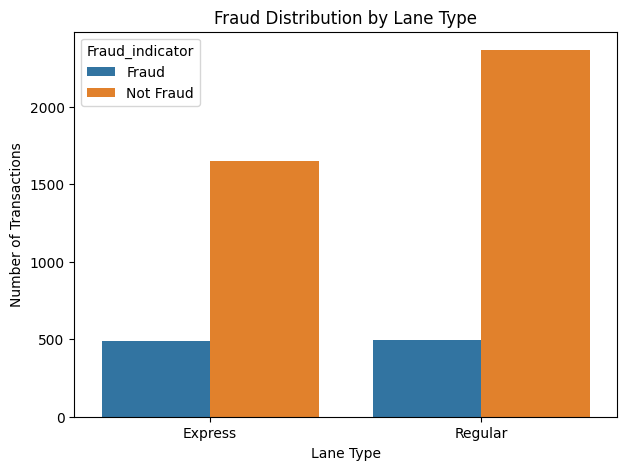

In [17]:
plt.figure(figsize=(7, 5))

sns.countplot(
    data=df,
    x="Lane_Type",
    hue="Fraud_indicator"
)

plt.title("Fraud Distribution by Lane Type")
plt.xlabel("Lane Type")
plt.ylabel("Number of Transactions")
plt.show()

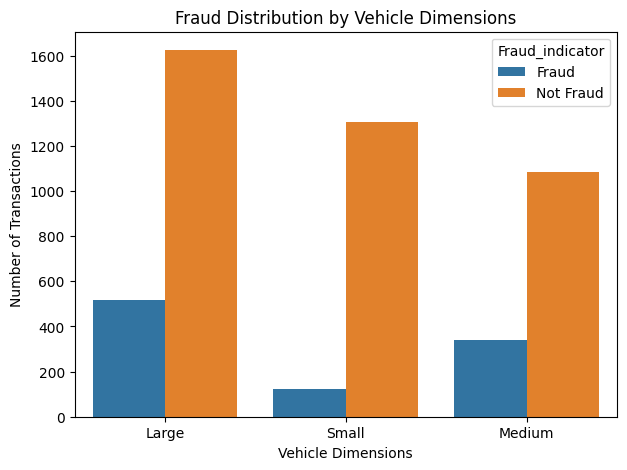

In [18]:
plt.figure(figsize=(7, 5))

sns.countplot(
    data=df,
    x="Vehicle_Dimensions",
    hue="Fraud_indicator"
)

plt.title("Fraud Distribution by Vehicle Dimensions")
plt.xlabel("Vehicle Dimensions")
plt.ylabel("Number of Transactions")
plt.show()

In [19]:
print("Unique geographical locations:", df["Geographical_Location"].nunique())

Unique geographical locations: 5


In [20]:
df.groupby("Fraud_indicator")["Geographical_Location"].nunique()

Fraud_indicator
Fraud        5
Not Fraud    5
Name: Geographical_Location, dtype: int64

Fraud Rate by Categories

In [21]:
#Fraud Rate by Vehicle Type

vehicle_fraud_rate = pd.crosstab(
    df["Vehicle_Type"],
    df["Fraud_indicator"],
    normalize="index"
) * 100

vehicle_fraud_rate

Fraud_indicator,Fraud,Not Fraud
Vehicle_Type,,
Bus,24.720670,75.279330
Car,17.086835,82.913165
Motorcycle,0.000000,100.000000
SUV,25.770308,74.229692
Sedan,22.549020,77.450980
Truck,22.128852,77.871148
Van,25.350140,74.649860


In [22]:
#Fraud Rate by Lane Type

lane_fraud_rate = pd.crosstab(
    df["Lane_Type"],
    df["Fraud_indicator"],
    normalize="index"
) * 100

lane_fraud_rate

Fraud_indicator,Fraud,Not Fraud
Lane_Type,,
Express,22.875817,77.124183
Regular,17.249825,82.750175


In [23]:
#Fraud Rate by Vehicle Dimensions

dimension_fraud_rate = pd.crosstab(
    df["Vehicle_Dimensions"],
    df["Fraud_indicator"],
    normalize="index"
) * 100

dimension_fraud_rate

Fraud_indicator,Fraud,Not Fraud
Vehicle_Dimensions,,
Large,24.207090,75.792910
Medium,23.949580,76.050420
Small,8.543417,91.456583


In [24]:
#Fraud Rate by Geographical Location

location_fraud_rate = pd.crosstab(
    df["Geographical_Location"],
    df["Fraud_indicator"],
    normalize="index"
) * 100

location_fraud_rate

Fraud_indicator,Fraud,Not Fraud
Geographical_Location,,
"12.84197701525119, 77.67547528176169",23.1,76.9
"12.936687032945434, 77.53113977439017",16.8,83.2
"13.042660878688794, 77.47580097259879",19.9,80.1
"13.059816123454882, 77.77068662374292",24.6,75.4
"13.21331620748757, 77.55413526894684",13.9,86.1


Check Duplicate Transactions

In [25]:
print("Number of duplicate rows:", df.duplicated().sum())

Number of duplicate rows: 0


In [26]:
print("Duplicate Transaction IDs:", df["Transaction_ID"].duplicated().sum())

Duplicate Transaction IDs: 0


Analyze the Timestamp

In [27]:
df["Timestamp"] = pd.to_datetime(df["Timestamp"])

print("Minimum Timestamp:", df["Timestamp"].min())
print("Maximum Timestamp:", df["Timestamp"].max())

Minimum Timestamp: 2023-01-01 00:00:00
Maximum Timestamp: 2023-12-31 21:45:00


In [28]:
df["Hour"] = df["Timestamp"].dt.hour

hourly_fraud = pd.crosstab(
    df["Hour"],
    df["Fraud_indicator"],
    normalize="index"
) * 100

hourly_fraud

Fraud_indicator,Fraud,Not Fraud
Hour,,
0,15.422886,84.577114
1,17.177914,82.822086
2,20.192308,79.807692
3,17.857143,82.142857
4,21.025641,78.974359
5,21.028037,78.971963
6,26.903553,73.096447
7,20.085470,79.914530
8,19.815668,80.184332


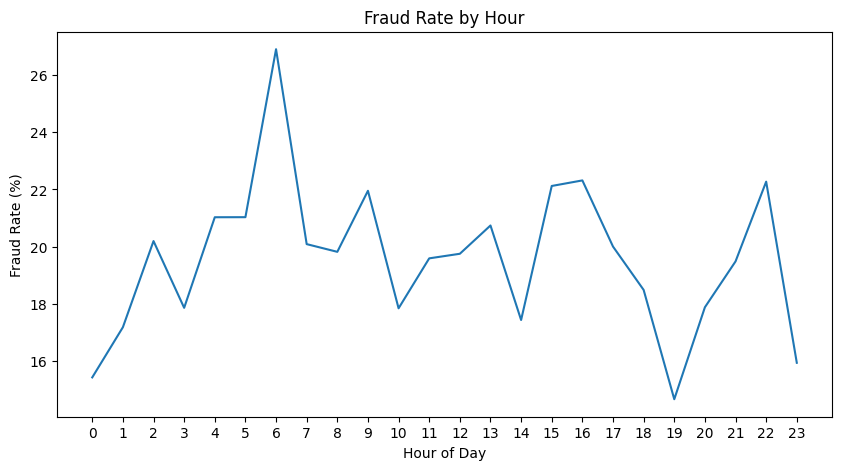

In [29]:
plt.figure(figsize=(10, 5))

sns.lineplot(
    data=hourly_fraud,
    x=hourly_fraud.index,
    y="Fraud"
)

plt.title("Fraud Rate by Hour")
plt.xlabel("Hour of Day")
plt.ylabel("Fraud Rate (%)")
plt.xticks(range(0, 24))
plt.show()

Check Feature Cardinality

In [30]:
unique_counts = df.nunique().sort_values()

unique_counts

Lane_Type                   2
Fraud_indicator             2
Vehicle_Dimensions          3
Geographical_Location       5
TollBoothID                 6
Vehicle_Type                7
Transaction_Amount         20
Amount_paid                23
Hour                       24
Vehicle_Speed              85
Timestamp                4423
FastagID                 4451
Transaction_ID           5000
Vehicle_Plate_Number     5000
dtype: int64

In [31]:
print("Unique values in each categorical column:")

categorical_columns = df.select_dtypes(include="object").columns

for column in categorical_columns:
    print(f"{column}: {df[column].nunique()}")

Unique values in each categorical column:
Vehicle_Type: 7
FastagID: 4451
TollBoothID: 6
Lane_Type: 2
Vehicle_Dimensions: 3
Geographical_Location: 5
Vehicle_Plate_Number: 5000
Fraud_indicator: 2


C:\Users\asus\AppData\Local\Temp\ipykernel_5636\2916420492.py:3: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  categorical_columns = df.select_dtypes(include="object").columns


Create the Modeling Dataset

In [32]:
#Create Features

model_df = df.copy()

# Create useful time features
model_df["Day"] = model_df["Timestamp"].dt.day
model_df["DayOfWeek"] = model_df["Timestamp"].dt.dayofweek

# Drop identifier and original timestamp columns
model_df = model_df.drop(
    columns=[
        "Transaction_ID",
        "FastagID",
        "Vehicle_Plate_Number",
        "Timestamp"
    ]
)

model_df.head()

,Vehicle_Type,TollBoothID,Lane_Type,Vehicle_Dimensions,Transaction_Amount,Amount_paid,Geographical_Location,Vehicle_Speed,Fraud_indicator,Hour,Day,DayOfWeek
0,Bus,A-101,Express,Large,350,120,"13.059816123454882, 77.77068662374292",65,Fraud,11,6,4
1,Car,B-102,Regular,Small,120,100,"13.059816123454882, 77.77068662374292",78,Fraud,14,7,5
2,Motorcycle,D-104,Regular,Small,0,0,"13.059816123454882, 77.77068662374292",53,Not Fraud,18,8,6
3,Truck,C-103,Regular,Large,350,120,"13.059816123454882, 77.77068662374292",92,Fraud,2,9,0
4,Van,B-102,Express,Medium,140,100,"13.059816123454882, 77.77068662374292",60,Fraud,6,10,1


Check the New Dataset

In [33]:
print("Modeling Dataset Shape:", model_df.shape)
print("\nColumns:")
print(model_df.columns.tolist())

Modeling Dataset Shape: (5000, 12)

Columns:
['Vehicle_Type', 'TollBoothID', 'Lane_Type', 'Vehicle_Dimensions', 'Transaction_Amount', 'Amount_paid', 'Geographical_Location', 'Vehicle_Speed', 'Fraud_indicator', 'Hour', 'Day', 'DayOfWeek']


In [34]:
model_df.isnull().sum()

Vehicle_Type             0
TollBoothID              0
Lane_Type                0
Vehicle_Dimensions       0
Transaction_Amount       0
Amount_paid              0
Geographical_Location    0
Vehicle_Speed            0
Fraud_indicator          0
Hour                     0
Day                      0
DayOfWeek                0
dtype: int64

Separate Features and Target

In [35]:
X = model_df.drop(columns=["Fraud_indicator"])
y = model_df["Fraud_indicator"]

print("Features shape:", X.shape)
print("Target shape:", y.shape)

Features shape: (5000, 11)
Target shape: (5000,)


In [36]:
print(y.value_counts())

Fraud_indicator
Not Fraud    4017
Fraud         983
Name: count, dtype: int64


Identify Categorical Columns

In [37]:
categorical_features = X.select_dtypes(include="object").columns.tolist()

print("Categorical features:")
print(categorical_features)

Categorical features:
['Vehicle_Type', 'TollBoothID', 'Lane_Type', 'Vehicle_Dimensions', 'Geographical_Location']


C:\Users\asus\AppData\Local\Temp\ipykernel_5636\1976957250.py:1: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  categorical_features = X.select_dtypes(include="object").columns.tolist()


Train-Test Split

In [38]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42,
    stratify=y
)

print("Training set:", X_train.shape)
print("Testing set:", X_test.shape)

print("\nTraining target distribution:")
print(y_train.value_counts())

print("\nTesting target distribution:")
print(y_test.value_counts())

Training set: (4000, 11)
Testing set: (1000, 11)

Training target distribution:
Fraud_indicator
Not Fraud    3214
Fraud         786
Name: count, dtype: int64

Testing target distribution:
Fraud_indicator
Not Fraud    803
Fraud        197
Name: count, dtype: int64


Encode Categorical Features

In [39]:
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder

categorical_features = X_train.select_dtypes(include="object").columns.tolist()
numerical_features = X_train.select_dtypes(exclude="object").columns.tolist()

preprocessor = ColumnTransformer(
    transformers=[
        (
            "categorical",
            OneHotEncoder(handle_unknown="ignore"),
            categorical_features
        ),
        (
            "numerical",
            "passthrough",
            numerical_features
        )
    ]
)

print("Categorical features:", categorical_features)
print("Numerical features:", numerical_features)

Categorical features: ['Vehicle_Type', 'TollBoothID', 'Lane_Type', 'Vehicle_Dimensions', 'Geographical_Location']
Numerical features: ['Transaction_Amount', 'Amount_paid', 'Vehicle_Speed', 'Hour', 'Day', 'DayOfWeek']


C:\Users\asus\AppData\Local\Temp\ipykernel_5636\91715210.py:4: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  categorical_features = X_train.select_dtypes(include="object").columns.tolist()


Transform Training and Testing Data

In [40]:
X_train_encoded = preprocessor.fit_transform(X_train)
X_test_encoded = preprocessor.transform(X_test)

print("Encoded training shape:", X_train_encoded.shape)
print("Encoded testing shape:", X_test_encoded.shape)

Encoded training shape: (4000, 29)
Encoded testing shape: (1000, 29)


In [44]:
from imblearn.over_sampling import SMOTE

print("SMOTE imported successfully!")

SMOTE imported successfully!


Apply SMOTE to the Training Data

In [45]:
smote = SMOTE(random_state=42)

X_train_smote, y_train_smote = smote.fit_resample(
    X_train_encoded,
    y_train
)

print("Before SMOTE:")
print(y_train.value_counts())

print("\nAfter SMOTE:")
print(y_train_smote.value_counts())

Before SMOTE:
Fraud_indicator
Not Fraud    3214
Fraud         786
Name: count, dtype: int64

After SMOTE:
Fraud_indicator
Not Fraud    3214
Fraud        3214
Name: count, dtype: int64


Train Random Forest Models

In [47]:
#Train Random Forest Without SMOTE

rf_model = RandomForestClassifier(
    n_estimators=200,
    random_state=42,
    n_jobs=-1
)

rf_model.fit(X_train_encoded, y_train)

rf_pred = rf_model.predict(X_test_encoded)

print("Random Forest without SMOTE trained successfully.")

Random Forest without SMOTE trained successfully.


Evaluate Random Forest Without SMOTE

In [48]:
#Classification Metrics

from sklearn.metrics import (
    classification_report,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score
)

rf_precision = precision_score(y_test, rf_pred, pos_label="Fraud")
rf_recall = recall_score(y_test, rf_pred, pos_label="Fraud")
rf_f1 = f1_score(y_test, rf_pred, pos_label="Fraud")

rf_prob = rf_model.predict_proba(X_test_encoded)[:, 1]

rf_roc_auc = roc_auc_score(
    (y_test == "Fraud").astype(int),
    rf_prob
)

print("Random Forest - Without SMOTE")
print("--------------------------------")
print(f"Precision: {rf_precision:.4f}")
print(f"Recall:    {rf_recall:.4f}")
print(f"F1-Score:  {rf_f1:.4f}")
print(f"ROC-AUC:   {rf_roc_auc:.4f}")

print("\nClassification Report:")
print(classification_report(y_test, rf_pred))

Random Forest - Without SMOTE
--------------------------------
Precision: 1.0000
Recall:    0.9391
F1-Score:  0.9686
ROC-AUC:   0.0006

Classification Report:
              precision    recall  f1-score   support

       Fraud       1.00      0.94      0.97       197
   Not Fraud       0.99      1.00      0.99       803

    accuracy                           0.99      1000
   macro avg       0.99      0.97      0.98      1000
weighted avg       0.99      0.99      0.99      1000



In [49]:
#Confusion Matrix

from sklearn.metrics import confusion_matrix

rf_cm = confusion_matrix(
    y_test,
    rf_pred,
    labels=["Not Fraud", "Fraud"]
)

print("Confusion Matrix:")
print(rf_cm)

Confusion Matrix:
[[803   0]
 [ 12 185]]


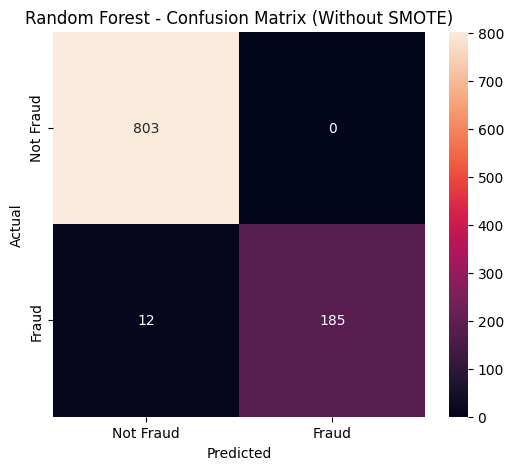

In [50]:
#Visualize Confusion Matrix

plt.figure(figsize=(6, 5))

sns.heatmap(
    rf_cm,
    annot=True,
    fmt="d",
    xticklabels=["Not Fraud", "Fraud"],
    yticklabels=["Not Fraud", "Fraud"]
)

plt.title("Random Forest - Confusion Matrix (Without SMOTE)")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()

Random Forest With SMOTE

In [51]:
#Train Random Forest With SMOTE

rf_smote_model = RandomForestClassifier(
    n_estimators=200,
    random_state=42,
    n_jobs=-1
)

rf_smote_model.fit(X_train_smote, y_train_smote)

rf_smote_pred = rf_smote_model.predict(X_test_encoded)

print("Random Forest with SMOTE trained successfully.")

Random Forest with SMOTE trained successfully.


Evaluate Random Forest With SMOTE

In [ ]:
#Metrics

rf_smote_precision = precision_score(
    y_test,
    rf_smote_pred,
    pos_label="Fraud"
)

rf_smote_recall = recall_score(
    y_test,
    rf_smote_pred,
    pos_label="Fraud"
)

rf_smote_f1 = f1_score(
    y_test,
    rf_smote_pred,
    pos_label="Fraud"
)

rf_smote_prob = rf_smote_model.predict_proba(X_test_encoded)[:, 1]

rf_smote_roc_auc = roc_auc_score(
    (y_test == "Fraud").astype(int),
    rf_smote_prob
)

print("Random Forest - With SMOTE")
print("--------------------------------")
print(f"Precision: {rf_smote_precision:.4f}")
print(f"Recall:    {rf_smote_recall:.4f}")
print(f"F1-Score:  {rf_smote_f1:.4f}")
print(f"ROC-AUC:   {rf_smote_roc_auc:.4f}")

print("\nClassification Report:")
print(classification_report(y_test, rf_smote_pred))

Random Forest - With SMOTE
--------------------------------
Precision: 1.0000
Recall:    0.9340
F1-Score:  0.9659
ROC-AUC:   0.0002

Classification Report:
              precision    recall  f1-score   support

       Fraud       1.00      0.93      0.97       197
   Not Fraud       0.98      1.00      0.99       803

    accuracy                           0.99      1000
   macro avg       0.99      0.97      0.98      1000
weighted avg       0.99      0.99      0.99      1000



In [53]:
#Confusion Matrix

rf_smote_cm = confusion_matrix(
    y_test,
    rf_smote_pred,
    labels=["Not Fraud", "Fraud"]
)

print("Confusion Matrix:")
print(rf_smote_cm)

Confusion Matrix:
[[803   0]
 [ 13 184]]


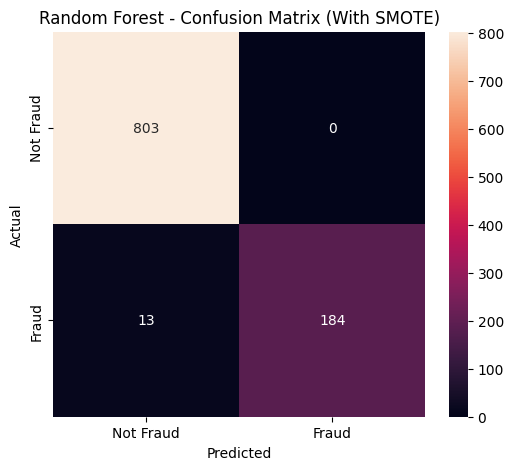

In [54]:
#Confusion Matrix Visualization

plt.figure(figsize=(6, 5))

sns.heatmap(
    rf_smote_cm,
    annot=True,
    fmt="d",
    xticklabels=["Not Fraud", "Fraud"],
    yticklabels=["Not Fraud", "Fraud"]
)

plt.title("Random Forest - Confusion Matrix (With SMOTE)")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()

XGBoost

In [56]:
import xgboost as xgb

print("XGBoost imported successfully!")

XGBoost imported successfully!


Train XGBoost

In [57]:
xgb_model = xgb.XGBClassifier(
    n_estimators=200,
    max_depth=6,
    learning_rate=0.1,
    random_state=42,
    eval_metric="logloss"
)

xgb_model.fit(X_train_encoded, (y_train == "Fraud").astype(int))

xgb_pred_numeric = xgb_model.predict(X_test_encoded)

xgb_pred = pd.Series(
    xgb_pred_numeric
).map({
    0: "Not Fraud",
    1: "Fraud"
})

print("XGBoost trained successfully.")

XGBoost trained successfully.


Evaluate XGBoost

In [58]:
#XGBoost Metrics

xgb_precision = precision_score(
    y_test,
    xgb_pred,
    pos_label="Fraud"
)

xgb_recall = recall_score(
    y_test,
    xgb_pred,
    pos_label="Fraud"
)

xgb_f1 = f1_score(
    y_test,
    xgb_pred,
    pos_label="Fraud"
)

xgb_prob = xgb_model.predict_proba(X_test_encoded)[:, 1]

xgb_roc_auc = roc_auc_score(
    (y_test == "Fraud").astype(int),
    xgb_prob
)

print("XGBoost")
print("--------------------------------")
print(f"Precision: {xgb_precision:.4f}")
print(f"Recall:    {xgb_recall:.4f}")
print(f"F1-Score:  {xgb_f1:.4f}")
print(f"ROC-AUC:   {xgb_roc_auc:.4f}")

print("\nClassification Report:")
print(classification_report(y_test, xgb_pred))

XGBoost
--------------------------------
Precision: 1.0000
Recall:    0.9746
F1-Score:  0.9871
ROC-AUC:   0.9947

Classification Report:
              precision    recall  f1-score   support

       Fraud       1.00      0.97      0.99       197
   Not Fraud       0.99      1.00      1.00       803

    accuracy                           0.99      1000
   macro avg       1.00      0.99      0.99      1000
weighted avg       1.00      0.99      0.99      1000



In [59]:
#XGBoost Confusion Matrix

xgb_cm = confusion_matrix(
    y_test,
    xgb_pred,
    labels=["Not Fraud", "Fraud"]
)

print("Confusion Matrix:")
print(xgb_cm)

Confusion Matrix:
[[803   0]
 [  5 192]]


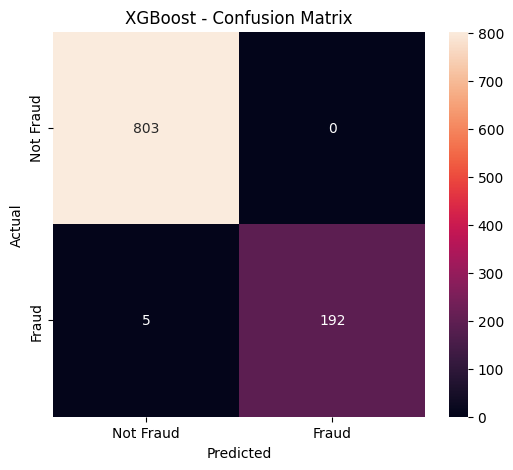

In [61]:
#Visualize

plt.figure(figsize=(6, 5))

sns.heatmap(
    xgb_cm,
    annot=True,
    fmt="d",
    xticklabels=["Not Fraud", "Fraud"],
    yticklabels=["Not Fraud", "Fraud"]
)

plt.title("XGBoost - Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()

Compare All Models

In [62]:
model_comparison = pd.DataFrame({
    "Model": [
        "Random Forest - Without SMOTE",
        "Random Forest - With SMOTE",
        "XGBoost"
    ],
    "Precision": [
        rf_precision,
        rf_smote_precision,
        xgb_precision
    ],
    "Recall": [
        rf_recall,
        rf_smote_recall,
        xgb_recall
    ],
    "F1-Score": [
        rf_f1,
        rf_smote_f1,
        xgb_f1
    ],
    "ROC-AUC": [
        rf_roc_auc,
        rf_smote_roc_auc,
        xgb_roc_auc
    ]
})

model_comparison

,Model,Precision,Recall,F1-Score,ROC-AUC
0,Random Forest - Without SMOTE,1.0,0.939086,0.968586,0.000569
1,Random Forest - With SMOTE,1.0,0.934010,0.965879,0.000237
2,XGBoost,1.0,0.974619,0.987147,0.994652


In [64]:
#Round the Values

model_comparison.round(4)

,Model,Precision,Recall,F1-Score,ROC-AUC
0,Random Forest - Without SMOTE,1.0,0.9391,0.9686,0.0006
1,Random Forest - With SMOTE,1.0,0.9340,0.9659,0.0002
2,XGBoost,1.0,0.9746,0.9871,0.9947


Correct Random Forest ROC-AUC

In [65]:
print("Random Forest classes:", rf_model.classes_)
print("Random Forest with SMOTE classes:", rf_smote_model.classes_)

Random Forest classes: ['Fraud' 'Not Fraud']
Random Forest with SMOTE classes: ['Fraud' 'Not Fraud']


In [66]:
#Correct the probabilities

rf_fraud_index = list(rf_model.classes_).index("Fraud")
rf_smote_fraud_index = list(rf_smote_model.classes_).index("Fraud")

rf_prob = rf_model.predict_proba(X_test_encoded)[:, rf_fraud_index]

rf_smote_prob = rf_smote_model.predict_proba(X_test_encoded)[:, rf_smote_fraud_index]

rf_roc_auc = roc_auc_score(
    (y_test == "Fraud").astype(int),
    rf_prob
)

rf_smote_roc_auc = roc_auc_score(
    (y_test == "Fraud").astype(int),
    rf_smote_prob
)

print(f"Corrected Random Forest ROC-AUC: {rf_roc_auc:.4f}")
print(f"Corrected Random Forest with SMOTE ROC-AUC: {rf_smote_roc_auc:.4f}")

Corrected Random Forest ROC-AUC: 0.9994
Corrected Random Forest with SMOTE ROC-AUC: 0.9998


In [67]:
#Recreate the comparison table

model_comparison = pd.DataFrame({
    "Model": [
        "Random Forest - Without SMOTE",
        "Random Forest - With SMOTE",
        "XGBoost"
    ],
    "Precision": [
        rf_precision,
        rf_smote_precision,
        xgb_precision
    ],
    "Recall": [
        rf_recall,
        rf_smote_recall,
        xgb_recall
    ],
    "F1-Score": [
        rf_f1,
        rf_smote_f1,
        xgb_f1
    ],
    "ROC-AUC": [
        rf_roc_auc,
        rf_smote_roc_auc,
        xgb_roc_auc
    ]
})

model_comparison.round(4)

,Model,Precision,Recall,F1-Score,ROC-AUC
0,Random Forest - Without SMOTE,1.0,0.9391,0.9686,0.9994
1,Random Forest - With SMOTE,1.0,0.9340,0.9659,0.9998
2,XGBoost,1.0,0.9746,0.9871,0.9947


Analyze Different Decision Thresholds

In [68]:
#Threshold Analysis

from sklearn.metrics import precision_score, recall_score, f1_score

thresholds = [0.10, 0.20, 0.30, 0.40, 0.50, 0.60, 0.70, 0.80, 0.90]

threshold_results = []

for threshold in thresholds:
    y_pred_threshold = (xgb_prob >= threshold).astype(int)

    precision = precision_score(
        (y_test == "Fraud").astype(int),
        y_pred_threshold,
        zero_division=0
    )

    recall = recall_score(
        (y_test == "Fraud").astype(int),
        y_pred_threshold,
        zero_division=0
    )

    f1 = f1_score(
        (y_test == "Fraud").astype(int),
        y_pred_threshold,
        zero_division=0
    )

    threshold_results.append([
        threshold,
        precision,
        recall,
        f1
    ])

threshold_results_df = pd.DataFrame(
    threshold_results,
    columns=["Threshold", "Precision", "Recall", "F1-Score"]
)

threshold_results_df.round(4)

,Threshold,Precision,Recall,F1-Score
0,0.1,0.9949,0.9848,0.9898
1,0.2,1.0000,0.9848,0.9923
2,0.3,1.0000,0.9848,0.9923
3,0.4,1.0000,0.9797,0.9897
4,0.5,1.0000,0.9746,0.9871
5,0.6,1.0000,0.9695,0.9845
6,0.7,1.0000,0.9594,0.9793
7,0.8,1.0000,0.9594,0.9793
8,0.9,1.0000,0.9442,0.9713


Plot Precision vs Recall

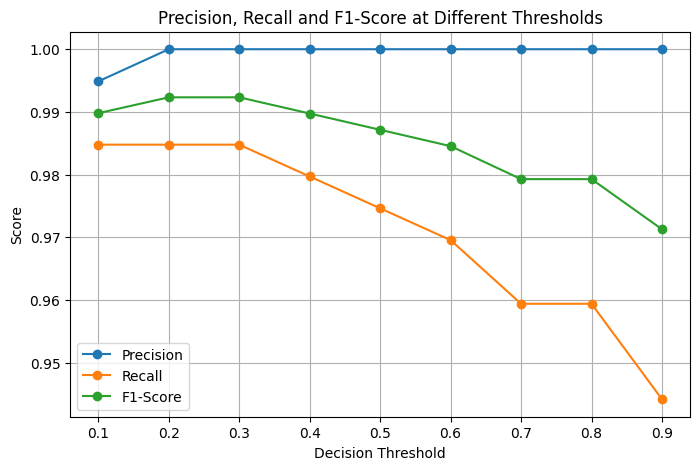

In [69]:
plt.figure(figsize=(8, 5))

plt.plot(
    threshold_results_df["Threshold"],
    threshold_results_df["Precision"],
    marker="o",
    label="Precision"
)

plt.plot(
    threshold_results_df["Threshold"],
    threshold_results_df["Recall"],
    marker="o",
    label="Recall"
)

plt.plot(
    threshold_results_df["Threshold"],
    threshold_results_df["F1-Score"],
    marker="o",
    label="F1-Score"
)

plt.xlabel("Decision Threshold")
plt.ylabel("Score")
plt.title("Precision, Recall and F1-Score at Different Thresholds")
plt.legend()
plt.grid(True)
plt.show()

Create Business Threshold Table

In [70]:
business_thresholds = threshold_results_df[
    threshold_results_df["Threshold"].isin([0.20, 0.30, 0.50, 0.70])
].copy()

business_thresholds.round(4)

,Threshold,Precision,Recall,F1-Score
1,0.2,1.0,0.9848,0.9923
2,0.3,1.0,0.9848,0.9923
4,0.5,1.0,0.9746,0.9871
6,0.7,1.0,0.9594,0.9793


Save Model Comparison

In [71]:
model_comparison.round(4).to_csv(
    "../outputs/model_comparison.csv",
    index=False
)

print("Model comparison saved successfully.")

Model comparison saved successfully.


Save Threshold Analysis

In [72]:
threshold_results_df.round(4).to_csv(
    "../outputs/threshold_analysis.csv",
    index=False
)

business_thresholds.round(4).to_csv(
    "../outputs/business_thresholds.csv",
    index=False
)

print("Threshold analysis files saved successfully.")

Threshold analysis files saved successfully.


Save Threshold Graph

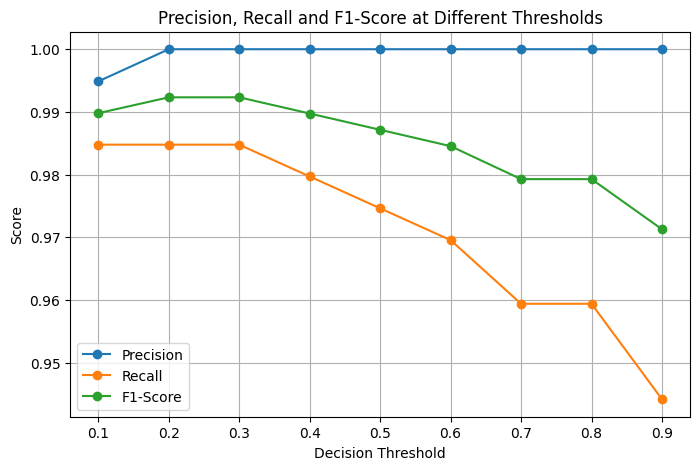

Threshold graph saved successfully.


In [73]:
plt.figure(figsize=(8, 5))

plt.plot(
    threshold_results_df["Threshold"],
    threshold_results_df["Precision"],
    marker="o",
    label="Precision"
)

plt.plot(
    threshold_results_df["Threshold"],
    threshold_results_df["Recall"],
    marker="o",
    label="Recall"
)

plt.plot(
    threshold_results_df["Threshold"],
    threshold_results_df["F1-Score"],
    marker="o",
    label="F1-Score"
)

plt.xlabel("Decision Threshold")
plt.ylabel("Score")
plt.title("Precision, Recall and F1-Score at Different Thresholds")
plt.legend()
plt.grid(True)

plt.savefig(
    "../outputs/threshold_analysis.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

print("Threshold graph saved successfully.")

Save the Confusion Matrices

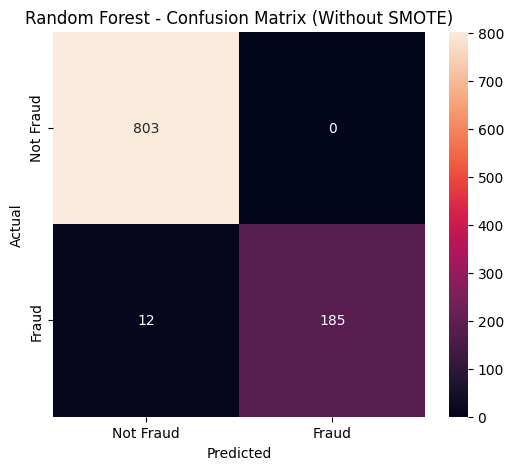

In [75]:
#Random Forest Without SMOTE

plt.figure(figsize=(6, 5))

sns.heatmap(
    rf_cm,
    annot=True,
    fmt="d",
    xticklabels=["Not Fraud", "Fraud"],
    yticklabels=["Not Fraud", "Fraud"]
)

plt.title("Random Forest - Confusion Matrix (Without SMOTE)")
plt.xlabel("Predicted")
plt.ylabel("Actual")

plt.savefig(
    "../outputs/confusion_matrix_random_forest.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

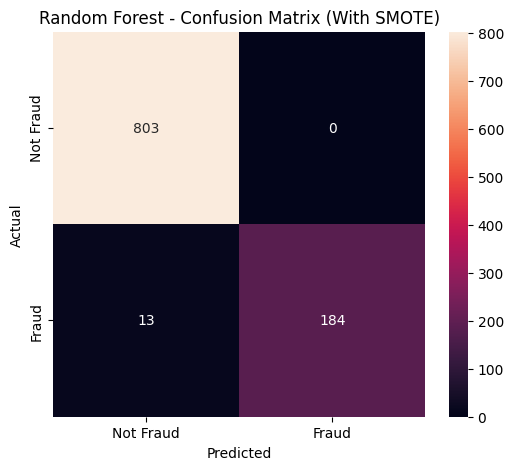

In [77]:
#Random Forest With SMOTE

plt.figure(figsize=(6, 5))

sns.heatmap(
    rf_smote_cm,
    annot=True,
    fmt="d",
    xticklabels=["Not Fraud", "Fraud"],
    yticklabels=["Not Fraud", "Fraud"]
)

plt.title("Random Forest - Confusion Matrix (With SMOTE)")
plt.xlabel("Predicted")
plt.ylabel("Actual")

plt.savefig(
    "../outputs/confusion_matrix_random_forest_smote.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

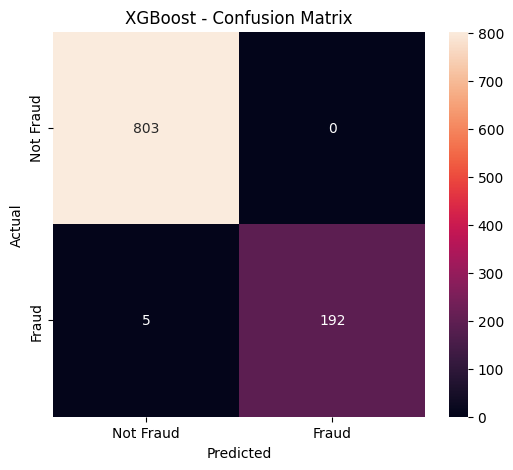

In [76]:
#XGBoost

plt.figure(figsize=(6, 5))

sns.heatmap(
    xgb_cm,
    annot=True,
    fmt="d",
    xticklabels=["Not Fraud", "Fraud"],
    yticklabels=["Not Fraud", "Fraud"]
)

plt.title("XGBoost - Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")

plt.savefig(
    "../outputs/confusion_matrix_xgboost.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

Save the Models


Import Joblib

In [78]:
import joblib

print("Joblib imported successfully.")

Joblib imported successfully.


In [79]:
joblib.dump(
    rf_model,
    "../models/random_forest_model.pkl"
)

joblib.dump(
    rf_smote_model,
    "../models/random_forest_smote_model.pkl"
)

joblib.dump(
    xgb_model,
    "../models/xgboost_model.pkl"
)

joblib.dump(
    preprocessor,
    "../models/preprocessor.pkl"
)

print("All models and preprocessing objects saved successfully.")

All models and preprocessing objects saved successfully.


Verify the Saved XGBoost Model

In [80]:
loaded_xgb_model = joblib.load(
    "../models/xgboost_model.pkl"
)

print("Saved XGBoost model loaded successfully.")

Saved XGBoost model loaded successfully.


In [81]:
#Test the Loaded Model

loaded_predictions = loaded_xgb_model.predict(X_test_encoded)

loaded_predictions = pd.Series(
    loaded_predictions
).map({
    0: "Not Fraud",
    1: "Fraud"
})

print("Predictions generated successfully.")
print(loaded_predictions.value_counts())

Predictions generated successfully.
Not Fraud    808
Fraud        192
Name: count, dtype: int64


In [82]:
#Verify Performance

loaded_precision = precision_score(
    y_test,
    loaded_predictions,
    pos_label="Fraud"
)

loaded_recall = recall_score(
    y_test,
    loaded_predictions,
    pos_label="Fraud"
)

loaded_f1 = f1_score(
    y_test,
    loaded_predictions,
    pos_label="Fraud"
)

print("Loaded XGBoost Performance")
print("---------------------------")
print(f"Precision: {loaded_precision:.4f}")
print(f"Recall:    {loaded_recall:.4f}")
print(f"F1-Score:  {loaded_f1:.4f}")

Loaded XGBoost Performance
---------------------------
Precision: 1.0000
Recall:    0.9746
F1-Score:  0.9871
